# Verifica — Exploración de datos (EDA)

Este notebook explora las **3 fuentes** que alimentan el motor (`data/verifica.duckdb`)
para **justificar las reglas del semáforo** (`core/riesgo.py`) con los datos reales.

> El demo lee esta muestra cacheada; la ingesta vive en `data/actualizar_datos.py`.

In [1]:
%matplotlib inline
import os, sys
import duckdb, pandas as pd
import matplotlib.pyplot as plt

RAIZ = os.path.abspath(".")
if not os.path.exists(os.path.join(RAIZ, "data", "verifica.duckdb")):
    RAIZ = os.path.abspath("..")
sys.path.insert(0, RAIZ)
con = duckdb.connect(os.path.join(RAIZ, "data", "verifica.duckdb"), read_only=True)
print("Conectado a verifica.duckdb")

Conectado a verifica.duckdb


## 1. Las tablas y su tamaño

In [2]:
for t in ["ssco", "osce", "padron"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:>7}: {n:,} filas")

   ssco: 110 filas
   osce: 9,543 filas
 padron: 61,837 filas


## 2. SSCO — empresas fantasma (rojo absoluto)

Relación oficial de Sujetos Sin Capacidad Operativa (D.L. 1532). Figurar aquí es
criterio determinante de **rojo**.

In [3]:
con.execute("SELECT ruc, razon_social, departamento, resolucion FROM ssco LIMIT 5").df()

,ruc,razon_social,departamento,resolucion
0,20607648272,INVARPERU E.I.R.L.,LIMA,Resolución de Intendencia N° 024-024-0086755/S...
1,20609411938,GRUPO PVH S.A.C.,HUANUCO,Resolución de Intendencia N° 024-024-0086751/S...
2,20610234233,CONSTRUCCIONES & INVERSIONES NAKAYAMA SOCIEDAD...,LIMA,Resolución de Intendencia N° 024-024-0087034/S...
3,20610542892,TRANSERVICES PERU E.I.R.L.,LIMA,Resolución de Intendencia N° 024-024-0086761/S...
4,20611921561,INVERSIONES Y NEGOCIOS LOS ZAFIROS S.A.C.,LIMA,Resolución de Intendencia N° 024-024-0087089/S...


## 3. OSCE — proveedores sancionados

La columna `vigente` distingue una inhabilitación **vigente** (rojo) de una **histórica**
(ámbar).

In [4]:
con.execute("SELECT vigente, COUNT(*) AS n FROM osce GROUP BY vigente ORDER BY n DESC").df()

,vigente,n
0,True,9543


## 4. Padrón RUC — estado y condición

Son las dos variables que más pesan en el color del semáforo.

In [5]:
estado = con.execute("SELECT estado, COUNT(*) AS n FROM padron GROUP BY estado ORDER BY n DESC").df()
cond = con.execute("SELECT condicion, COUNT(*) AS n FROM padron GROUP BY condicion ORDER BY n DESC").df()
display(estado, cond)

,estado,n
0,ACTIVO,54713
1,BAJA DE OFICIO,4592
2,SUSPENSION TEMPORAL,1751
3,BAJA DEFINITIVA,540
4,BAJA PROV. POR OFICI,121
5,BAJA MULT.INSCR. Y O,120


,condicion,n
0,HABIDO,57847
1,NO HABIDO,2218
2,NO HALLADO OTROS MOT,311
3,NO HALLADO CERRADO,306
4,NO HALLADO SE MUDO D,289
5,NO APLICABLE,210
6,NO HALLADO DESTINATA,181
7,NO HALLADO NRO.PUERT,156
8,NO HALLADO NO EXISTE,125
9,NO HALLADO RECHAZADO,98


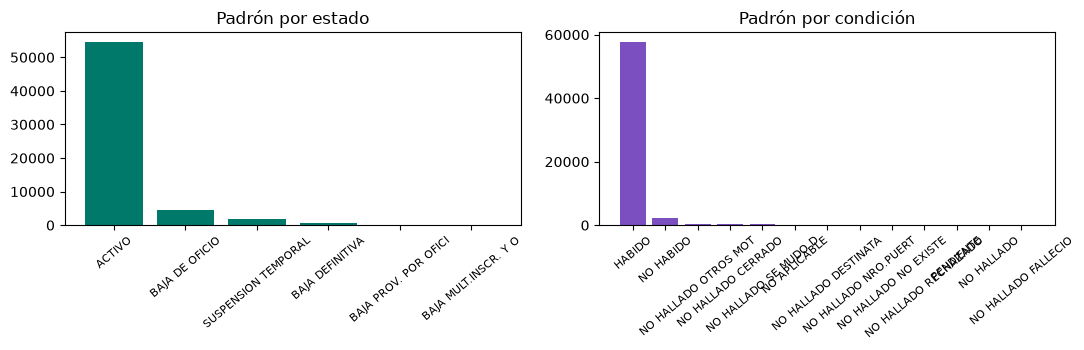

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(estado["estado"].astype(str), estado["n"], color="#00796b")
ax[0].set_title("Padrón por estado"); ax[0].tick_params(axis="x", rotation=40, labelsize=8)
ax[1].bar(cond["condicion"].astype(str), cond["n"], color="#7b4fbf")
ax[1].set_title("Padrón por condición"); ax[1].tick_params(axis="x", rotation=40, labelsize=8)
plt.tight_layout(); plt.show()

## 5. El cruce: qué dispara rojo / ámbar

Los RUCs del padrón que **además** están en SSCO o en OSCE vigente son los casos de riesgo.

In [7]:
en_ssco = con.execute("SELECT COUNT(*) FROM padron WHERE ruc IN (SELECT ruc FROM ssco)").fetchone()[0]
en_osce = con.execute("SELECT COUNT(*) FROM padron WHERE ruc IN (SELECT ruc FROM osce)").fetchone()[0]
en_osce_vig = con.execute("SELECT COUNT(*) FROM padron WHERE ruc IN (SELECT ruc FROM osce WHERE vigente)").fetchone()[0]
print(f"RUCs del padron tambien en SSCO       : {en_ssco}")
print(f"RUCs del padron tambien en OSCE       : {en_osce}")
print(f"   ... de ellos con sancion VIGENTE   : {en_osce_vig}")

RUCs del padron tambien en SSCO       : 107
RUCs del padron tambien en OSCE       : 6069
   ... de ellos con sancion VIGENTE   : 6069


## 6. El semáforo aplicado (motor real sobre una muestra)

Corremos `verificar_ruc()` sobre 600 RUCs al azar del padrón para ver la distribución
de colores que produce el motor.

In [8]:
from core.verificador import verificar_ruc
muestra = con.execute("SELECT ruc FROM padron USING SAMPLE 600 ROWS").df()["ruc"].tolist()
niveles = pd.Series([verificar_ruc(r).nivel for r in muestra]).value_counts()
niveles

VERDE    486
ROJO      99
AMBAR     15
Name: count, dtype: int64

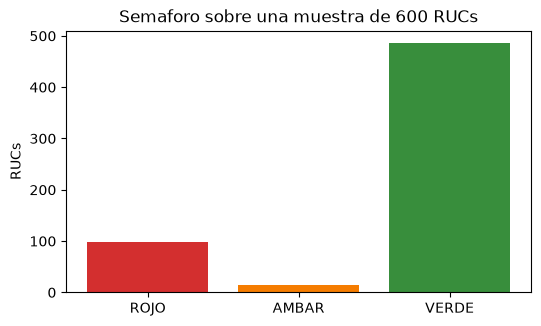

In [9]:
orden = [n for n in ["ROJO", "AMBAR", "VERDE", "DESCONOCIDO"] if n in niveles.index]
colores = {"ROJO": "#d32f2f", "AMBAR": "#f57c00", "VERDE": "#388e3c", "DESCONOCIDO": "#9e9e9e"}
plt.figure(figsize=(6, 3.4))
plt.bar(orden, [int(niveles[n]) for n in orden], color=[colores[n] for n in orden])
plt.title("Semaforo sobre una muestra de 600 RUCs"); plt.ylabel("RUCs")
plt.show()

## 7. Conclusión — las reglas (en `core/riesgo.py`)

A partir de lo anterior, el semáforo queda así (conservador: gana la señal más grave):

- 🔴 **ROJO:** figura en SSCO, **o** estado `BAJA…`, **o** condición `NO HABIDO`, **o** inhabilitación OSCE **vigente**.
- 🟡 **ÁMBAR:** estado `SUSPENSION TEMPORAL`, **o** condición `NO HALLADO` / `PENDIENTE`, **o** sanción OSCE **histórica**.
- 🟢 **VERDE:** `ACTIVO` + `HABIDO`, sin SSCO ni sanciones.

**Filosofía:** un falso verde (decir "confiable" a una fantasma) es mucho peor que un falso ámbar.
El nivel lo deciden estas reglas transparentes; Gemini lo toma como criterio y redacta el reporte.